In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import RandomForestClassifier , RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model  import LogisticRegression, LinearRegression
from sklearn.metrics import (recall_score, precision_score, f1_score, 
accuracy_score , mean_squared_error, r2_score, roc_auc_score, roc_curve)

from scipy import stats

In [35]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/p1.csv')
df.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=B,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=B,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=B,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=B,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=B,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [36]:
df.isna().sum().to_frame().T

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0,0,0,1,18,1,0,0,0,10,0,0,1


In [37]:
# NA COlumns만 추출 
na_cols = df.columns[df.isna().any()].tolist()

4.276315789473683

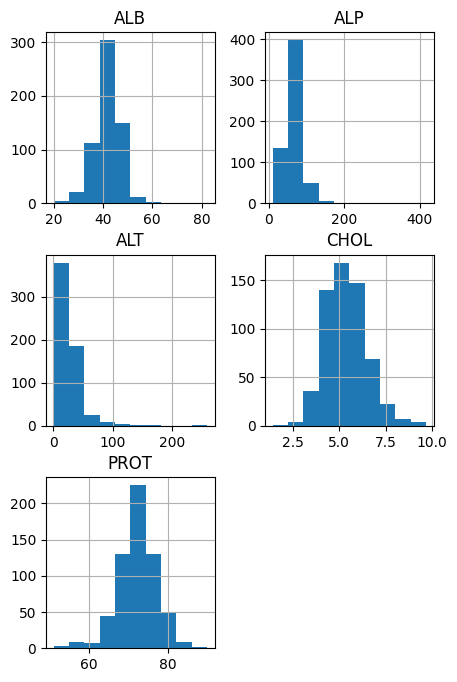

In [38]:
fig, axes = plt.subplots(1, 4, figsize = (5,8))
for axes, col in zip(axes, df[na_cols].columns) : 
    df[na_cols].hist(ax = axes)


# 1) 중위수 대체 
median_df = df.copy()
for col in median_df.columns : 
    if pd.isna(median_df[col]).any() : 
        median_df[col] = median_df[col].fillna(median_df[col].median())

#median_df.isna().sum()

# 2) Drop_na
nadrop = df.dropna()
drop_ratio =  (1- len(nadrop) / len(df)) * 100 
drop_ratio

In [33]:
# 원본 
print('원본')
display(df.describe())

print('중위수 대체')
display(median_df.describe())

print('결측치제거')
display(nadrop.describe())

print('''
데이터의 손실이 없고, 평균과 표준편차의 변화가 거의 없어 원본을 유지하는 중위수로 대체한다. 
삭제의 경우 AST, GGT의 평균이 달라저 원본의 분포의 특성이 손실되기 떄문이다. 
''')

원본


,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,608.000000,607.000000,590.000000,607.000000,608.000000,608.000000,608.000000,598.000000,608.000000,608.000000,607.000000
mean,47.291118,41.818781,67.821017,27.601318,34.369408,11.474013,8.204885,5.378829,81.513158,38.243914,72.253213
std,9.992705,5.406717,25.274423,21.227539,32.622442,19.770558,2.168400,1.119394,49.720652,51.953220,4.932252
min,19.000000,20.000000,11.300000,0.900000,12.000000,1.800000,1.420000,1.430000,8.000000,4.500000,51.000000
25%,39.000000,39.000000,52.500000,16.400000,21.600000,5.300000,6.950000,4.620000,68.000000,15.700000,69.450000
50%,47.000000,42.000000,66.000000,23.000000,25.850000,7.300000,8.270000,5.300000,77.000000,23.250000,72.200000
75%,54.000000,45.250000,79.525000,32.750000,32.800000,11.300000,9.585000,6.075000,88.000000,39.200000,75.400000
max,77.000000,82.200000,416.600000,258.000000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


중위수 대체


,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,608.000000,608.000000,608.000000,608.000000,608.000000,608.000000,608.000000,608.000000,608.000000,608.000000,608.000000
mean,47.291118,41.819079,67.767105,27.593750,34.369408,11.474013,8.204885,5.377533,81.513158,38.243914,72.253125
std,9.992705,5.402266,24.898775,21.210867,32.622442,19.770558,2.168400,1.110180,49.720652,51.953220,4.928188
min,19.000000,20.000000,11.300000,0.900000,12.000000,1.800000,1.420000,1.430000,8.000000,4.500000,51.000000
25%,39.000000,39.000000,52.900000,16.400000,21.600000,5.300000,6.950000,4.627500,68.000000,15.700000,69.475000
50%,47.000000,42.000000,66.000000,23.000000,25.850000,7.300000,8.270000,5.300000,77.000000,23.250000,72.200000
75%,54.000000,45.225000,79.025000,32.675000,32.800000,11.300000,9.585000,6.060000,88.000000,39.200000,75.400000
max,77.000000,82.200000,416.600000,258.000000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


결측치제거


,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.00000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,47.295533,41.831443,67.651890,25.666838,33.325086,11.09433,8.212337,5.402646,81.909107,36.835567,72.106357
std,9.863890,5.369272,25.148941,14.920906,32.357234,17.49429,2.151660,1.114920,50.669976,51.409352,4.857867
min,23.000000,23.000000,11.300000,0.900000,12.000000,1.80000,1.420000,1.430000,8.000000,4.500000,51.000000
25%,39.000000,39.000000,52.500000,16.325000,21.425000,5.30000,6.950000,4.630000,68.000000,15.450000,69.300000
50%,47.000000,41.950000,66.000000,22.500000,25.600000,7.15000,8.265000,5.310000,77.000000,22.650000,72.100000
75%,54.000000,45.175000,79.300000,31.750000,31.600000,11.00000,9.565000,6.087500,89.000000,36.200000,75.200000
max,77.000000,82.200000,416.600000,118.100000,324.000000,209.00000,16.410000,9.670000,1079.100000,650.900000,86.500000


1-2 이상치 확인 하고 처리 여부를 판단해 반영

<Axes: >

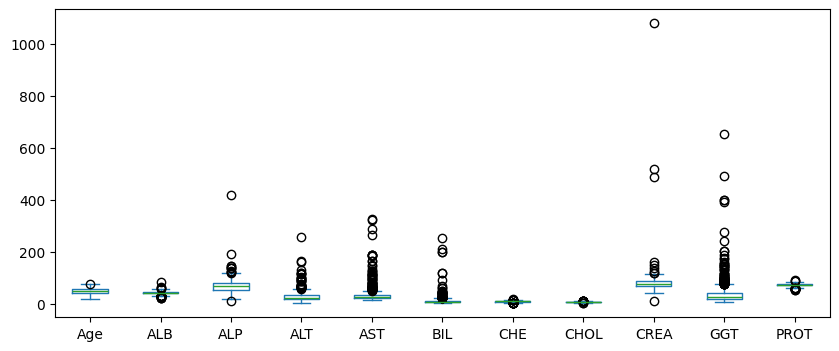

In [43]:
out_df = median_df.copy()
num_cols = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']


out_df[num_cols].plot(kind = 'box' , figsize = (10, 4))
print('''
이상치가 존재하지만 간염 정보를 구분 짓는 요인이 될 수 있기 때문에 제거하지 않는다. 
''')

1-3 위 전처리 결과를 바탕으로 EDA진행, 종속변수 기준으로 독립 변수의 차이를 확인 (시각화포함)

In [55]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  608 non-null    object 
 1   Age       608 non-null    int64  
 2   Sex       608 non-null    object 
 3   ALB       608 non-null    float64
 4   ALP       608 non-null    float64
 5   ALT       608 non-null    float64
 6   AST       608 non-null    float64
 7   BIL       608 non-null    float64
 8   CHE       608 non-null    float64
 9   CHOL      608 non-null    float64
 10  CREA      608 non-null    float64
 11  GGT       608 non-null    float64
 12  PROT      608 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 61.9+ KB


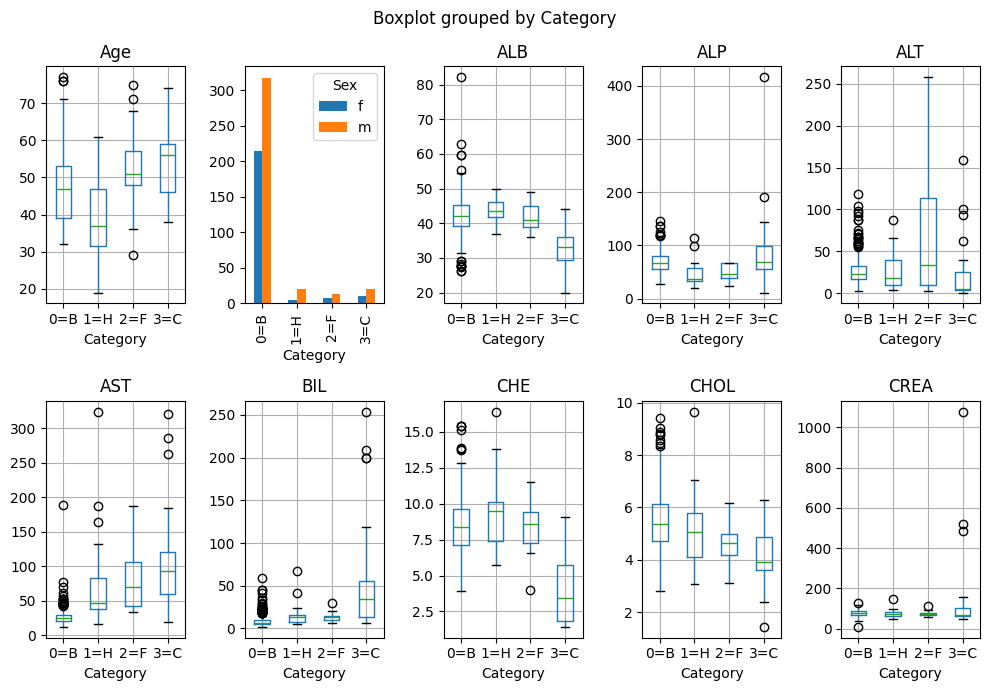

  Column       p_value             decision
0    Age  9.425871e-08  적어도 하나의 그룹의 평균은 다르다
1    Sex  1.193555e-01                 독립이다
2    ALB  6.198460e-21  적어도 하나의 그룹의 평균은 다르다
3    ALP  2.495506e-11  적어도 하나의 그룹의 평균은 다르다
4    ALT  2.492332e-11  적어도 하나의 그룹의 평균은 다르다
5    AST  4.194864e-74  적어도 하나의 그룹의 평균은 다르다
6    BIL  4.000225e-48  적어도 하나의 그룹의 평균은 다르다
7    CHE  3.336676e-32  적어도 하나의 그룹의 평균은 다르다
8   CHOL  8.126567e-13  적어도 하나의 그룹의 평균은 다르다
9   CREA  2.680767e-09  적어도 하나의 그룹의 평균은 다르다


In [62]:
df3 = out_df.copy()

eda_cols = ['Age','Sex','ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']

fig, axes = plt.subplots(2,5 ,figsize = (10, 7))
res = []
for axes, col in zip(axes.flatten(), eda_cols)  : 
    if  col == 'Sex' : 
        tab = pd.crosstab(df3['Category'] , df3[col])
        s, p , _ , _ = stats.chi2_contingency(tab)
        d = '독립이 아니다' if p < 0.05 else '독립이다'

        tab.plot(kind = 'bar', ax = axes)

    else : 
        groups = [group[col] for name, group in df3.groupby('Category')]
        s, p = stats.f_oneway(* groups)
        d = '적어도 하나의 그룹의 평균은 다르다' if p < 0.05 else '평균이 모두 같다' 

        df3.boxplot(column = col, by = 'Category', ax = axes)

    
    res.append([col, p, d])

plt.tight_layout()
plt.show()

print(pd.DataFrame(res, columns = ['Column','p_value' ,'decision']))

1-4 주성분 분석을 수행해 새로운 설명변수를 도출 할 수 있는지 검토하고 결과를 제시 

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11
Ratio,0.216055,0.164494,0.128432,0.098751,0.080507,0.070713,0.066824,0.056666,0.044176,0.042638,0.030745
Cumsum,0.216055,0.380548,0.508980,0.607731,0.688238,0.758951,0.825775,0.882441,0.926617,0.969255,1.000000



PC 8까지 누적 설명 분산이 88%으로 7개의ㅣ 주성분으로 전체 분산의 82.6%설명할 수 있다. 
PC_7까지의 새로운 설명 변수로 채택하여, 11개 중 7개로 축소하여 다중 공선성을 완ㅘ 시킬 수 있다. 



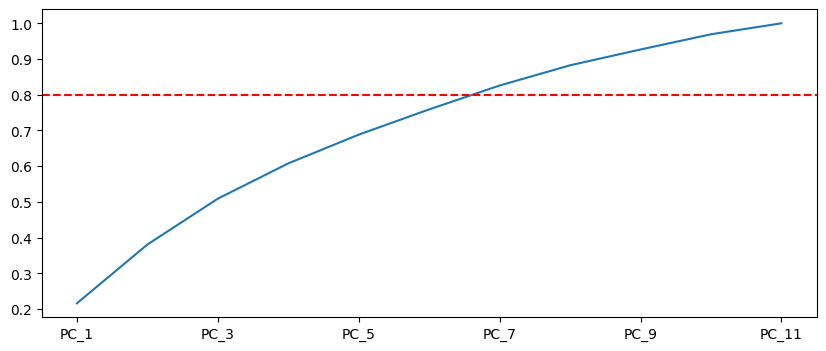

In [85]:
from sklearn.decomposition import PCA

# df3 으로 연속형 변수로 수행 
X = df3[['Age','ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']]

# 표준화 (PCA전 필수)
ss = StandardScaler()
scaled_x = ss.fit_transform(X)


#  PCA 
pca = PCA()
pca.fit(scaled_x)

pca_df = pd.DataFrame({
    'Ratio' : pca.explained_variance_ratio_, 
    'Cumsum' : pca.explained_variance_ratio_.cumsum()
})

pca_df.index = [f'PC_{i+1}' for i in range(len(pca_df)) ]
display(pca_df.T)

# scree plot
plt.figure(figsize = (10, 4))
pca_df['Cumsum'].plot(kind = 'line')
plt.axhline(0.8, color = 'red' , linestyle = '--')

print('''
PC 8까지 누적 설명 분산이 88%으로 7개의ㅣ 주성분으로 전체 분산의 82.6%설명할 수 있다. 
PC_7까지의 새로운 설명 변수로 채택하여, 11개 중 7개로 축소하여 다중 공선성을 완ㅘ 시킬 수 있다. 
''')

In [93]:
# df3 으로 연속형 변수로 수행 
X = df3[['Age','ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']]

# 표준화 (PCA전 필수)
ss = StandardScaler()
scaled_x = ss.fit_transform(X)


#  PCA 
pca = PCA(n_components= 6)
pca_df6 = pd.DataFrame(pca.fit_transform(scaled_x)) 
pca_df6.columns = [f'PC_{i+1}' for i in range(len(pca_df6.columns))]
pca_df6.head(5)

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6
0,-0.767983,-2.057126,-1.026127,1.508011,0.338358,-0.398198
1,1.043175,-0.284339,-0.608457,0.737818,0.146555,-1.134728
2,1.054275,0.968914,-1.496273,0.907567,-0.166496,-0.515511
3,0.272381,-0.385450,-1.555615,0.753429,-0.194482,-0.636395
4,-0.098605,-0.654843,-0.533688,0.808200,0.998394,-1.262346


1-5 데이터 불균형이 왜 문제인지 설명하고 해결방법 2가지 제시 

In [96]:
print(df3['Category'].value_counts())

print('''
B를 제외하고 나머지 3개의 클래스가 4%미만으로 불균형 상태가 심각하다. 
불균형 상태에서 정확도를 평가하면 모든 정상을 예측해도 대략 87% (정상_B) 만 나오기 때문에 
실제 질병 탐지 성능을 반영하지 못한다. 

SMOTE기법을 사용하여 균형을 맞추고, class_weight로 소수 클래스 오분류에 더 높은 패널티를 부여한다
F1(macro) 기준으로 두 방법을 비교하여 소수 클래스 탐지 성능이 높은 방법을 채택한다. 
''')


Category
0=B    533
3=C     30
1=H     24
2=F     21
Name: count, dtype: int64

B를 제외하고 나머지 3개의 클래스가 4%미만으로 불균형 상태가 심각하다. 
불균형 상태에서 정확도를 평가하면 모든 정상을 예측해도 대략 87% (정상_B) 만 나오기 때문에 
실제 질병 탐지 성능을 반영하지 못한다. 

SMOTE기법을 사용하여 균형을 맞추고, class_weight로 소수 클래스 오분류에 더 높은 패널티를 부여한다
F1(macro) 기준으로 두 방법을 비교하여 소수 클래스 탐지 성능이 높은 방법을 채택한다. 



1-6 불균형 데이터 분류에 적합한 평가 지표 3개를 제시하고 이유를 설명 

In [97]:
print('''
F1-Score : 정밀도와 재현율의 조화 평균으로, 두 지표를 동시에 고려한 균형 잡힌 평가 지표이다. 
            average = macro를 적용하면 클래별 F1을 단순 평균하여 다수 클래스와 소수 클래스를 동등하게 취급한다. 
            F1(macro)는 소수 클래스를 놓치면 수치가 낮아 짐으로 불균형 데이터에서 정확도를 신뢰할 수 있다. 

Recall : 실제 양성 중 양성으로 예측한 비율로 TP / TP + FN 으로 계산된다. Recall이 낮다는 것은 
         실제 환자를 정상으로 놓치고 있다는 의미임으로, 소수 클래스 탐지가 중요하다. 

Precision: 양성으로 예측한 것들 중에 실제 양성인 비율 
           정상으로 예측했는데 정상이 아닌 경우 - 추가 검사 - 비교적 덜 심각 

ROC-AUC : FPR (위양성률)과 TPR (재현율)의 관계를 나타내는 지표로서, 각 클래스를 나머지 전체와 비교하여 
          클래스별 분류 성능을 개별적으로 확인 할 수 있다. 

''')


F1-Score : 정밀도와 재현율의 조화 평균으로, 두 지표를 동시에 고려한 균형 잡힌 평가 지표이다. 
            average = macro를 적용하면 클래별 F1을 단순 평균하여 다수 클래스와 소수 클래스를 동등하게 취급한다. 
            F1(macro)는 소수 클래스를 놓치면 수치가 낮아 짐으로 불균형 데이터에서 정확도를 신뢰할 수 있다. 

Recall : 실제 양성 중 양성으로 예측한 비율로 TP / TP + FN 으로 계산된다. Recall이 낮다는 것은 
         실제 환자를 정상으로 놓치고 있다는 의미임으로, 소수 클래스 탐지가 중요하다. 

Precision: 양성으로 예측한 것들 중에 실제 양성인 비율 
           정상으로 예측했는데 정상이 아닌 경우 - 추가 검사 - 비교적 덜 심각 

ROC-AUC : FPR (위양성률)과 TPR (재현율)의 관계를 나타내는 지표로서, 각 클래스를 나머지 전체와 비교하여 
          클래스별 분류 성능을 개별적으로 확인 할 수 있다. 




1-7 정상(0), 비정상 (1,2,3)으로 이진화한 뒤 불균형 처리 2가지와 3개의 평가 지표를 사용해 각각 평가 
- 전처리 후 index을 0부터 다시 부여 
- Index % 5 == 0 은 테스트, 나머지는 train
- 분류모델은 3가지 

,0,1,2,3
0,RandomForeset,0.912394,0.947975,0.988474
1,Decision_Tree,0.760784,0.839252,0.839252
2,SCV,0.897479,0.943302,0.995639


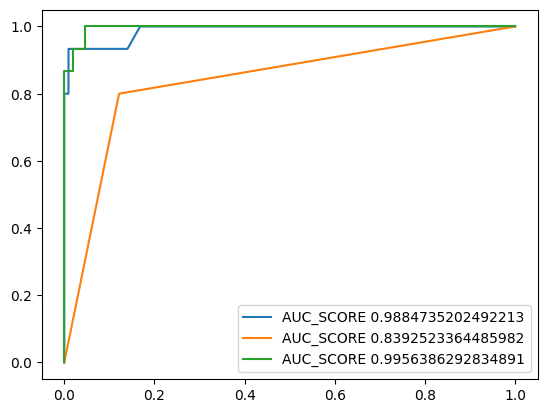

In [139]:
m_df = df3.copy()

# Cateogory 이진화
m_df['Category'] = m_df['Category'].apply(lambda x : 0 if x.split('=')[0] =='0' else 1).astype(int)

# 전처리 
m_df['Sex'] = m_df['Sex'].map({'m': 1, 'f':0})

# Sex 매핑 , PCA 주성분 추가 -> Model_df 최종 (인덱스 재부여)
model_df = pd.concat([m_df[['Category', 'Sex']], pca_df6], axis = 1).reset_index(drop = True)

# 2. Index 기준으로 분리 
train_set = model_df[model_df.index % 5 != 0]
x_train = train_set.drop(columns = 'Category', axis = 1)
y_train = train_set['Category']

test_set = model_df[model_df.index % 5 == 0]
x_test = test_set.drop(columns = 'Category', axis = 1)
y_test = test_set['Category']


# 3. 불균형 처리 (Train만)
smote = SMOTE(random_state = 42)
sm_x, sm_y = smote.fit_resample(x_train, y_train)

# 4. 모델 학습 및 평가 
def eval (name, model) : 
    model.fit(sm_x, sm_y)
    pred = model.predict(x_test)
    pred_proba = model.predict_proba(x_test)[:, 1]
    
    f1 = f1_score(y_test, pred, average = 'macro')
    recall = recall_score(y_test, pred, average = 'macro')

    auc = roc_auc_score(y_test, pred_proba)

    fpr, tpr , _ = roc_curve(y_test, pred_proba)
    plt.plot(fpr, tpr, label = f'AUC_SCORE {auc}')
    plt.legend()
    
    return name, model, f1, recall , auc

res = []
for name, model in [['RandomForeset', RandomForestClassifier()],
                    ['Decision_Tree', DecisionTreeClassifier()] ,
                    ['SCV', SVC(probability= True)]] : 
    name, model, f1, recall, auc = eval(name, model)
    res.append([name, f1, recall, auc])

pd.DataFrame(res)

1-8 1의 전처리 결과에서 0을 제외한 1,2,3만 사용해 다중 분류 모델을 학습 
- Index 0다시 부여 
- Index % 5 ==0 은 test, 나머지는 train 

In [185]:
# 중위수 대체, 이상치까지의 DF

# 1. 전처리 데이터 - df3
df4 = df3.copy() 

filter_df = df4[df4['Category'] != '0=B']
filter_df['Category'] = filter_df['Category'].str.split('=').str[0].astype(int)

filter_df['Sex'] = filter_df['Sex'].map({'m' : 1, 'f': 0})  

# Category, Sex 만 추출 
filter_df  

# scaling 처리
X = filter_df[['Age','ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']]
ss = StandardScaler()
scaled_x = pd.DataFrame(ss.fit_transform(X) , columns = X.columns)
scaled_x

# y + Sex 
f_df = filter_df[['Category','Sex']].reset_index(drop = True)


,0,1,2,3
0,RandomForeset,0.711111,0.711111,0.918979
1,Decision_Tree,0.777778,0.783333,0.844697
2,SCV,0.731313,0.738889,0.880875


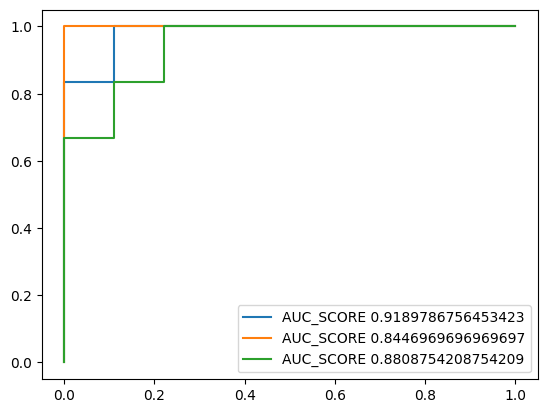

In [202]:
multi_df = pd.concat([f_df, scaled_x], axis = 1)

# 2. Index 기준으로 분리 
train_set = multi_df[multi_df.index % 5 != 0]
x_train = train_set.drop(columns = 'Category', axis = 1)
y_train = train_set['Category']

test_set = multi_df[multi_df.index % 5 == 0]
x_test = test_set.drop(columns = 'Category', axis = 1)
y_test = test_set['Category']


# 3. 불균형 처리 (Train만)
smote = SMOTE(random_state = 42)
sm_x, sm_y = smote.fit_resample(x_train, y_train)

# 4. 모델 학습 및 평가 
def eval (name, model) : 
    model.fit(sm_x, sm_y)
    pred = model.predict(x_test)
    pred_proba = model.predict_proba(x_test) #다중분류제거
    
    f1 = f1_score(y_test, pred, average = 'macro')
    recall = recall_score(y_test, pred, average = 'macro')

    # 다중 분류 ovr 추가
    auc = roc_auc_score(y_test, pred_proba , 
                       multi_class = 'ovr' , 
                       average = 'macro')

    # --- ROC Curve 클래스별로 그리기 ---------------- 
    classes = sorted(y_test.unique()) 
    for i, c in enumerate(classes) : 
        fpr, tpr , _ = roc_curve(
                                (y_test == c).astype(int), 
                                pred_proba[:, i])
        
    plt.plot(fpr, tpr, label = f'AUC_SCORE {auc}')
    plt.legend()
    
    return name, model, f1, recall , auc

res = [] 
mlst = []
for name, model in [['RandomForeset', RandomForestClassifier()],
                    ['Decision_Tree', DecisionTreeClassifier()] ,
                    ['SCV', SVC(probability= True, kernel = 'linear')]] : 
    name, model, f1, recall, auc = eval(name, model)
    res.append([name, f1, recall, auc])
    mlst.append([name, model])

pd.DataFrame(res)

1-9 모델 결과와 평가지표를 바탕으로 간염여부에 영향을 미치는 요소 논의

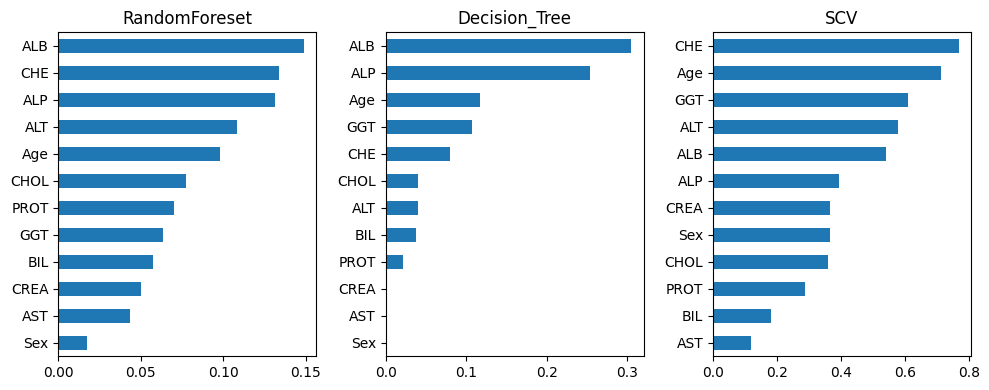

In [203]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, (name, model) in zip(axes, mlst):  
    if name == 'SCV':
        imp_svc = abs(model.coef_).mean(axis=0)
        f       = model.feature_names_in_
        f_imp   = pd.Series(imp_svc, index=f).sort_values()
        f_imp.plot(kind='barh', ax=ax)
        ax.set_title(name)
    else:
        imp   = model.feature_importances_
        f     = model.feature_names_in_
        f_imp = pd.Series(imp, index=f).sort_values()
        f_imp.plot(kind='barh', ax=ax)
        ax.set_title(name)

plt.tight_layout()
plt.show()

2-1 승하차 데이터에서 X-5, X-22가 모두 0인 행은 제외하고, 기초통계량을 구합니다. 
- 날짜, 호선, 역번호, 시간대별 승객수 합계 , 컬럼명은 users , 결측치는 0 
- 날씨 0, 그 외 결측치는 직전값으로 대치 
- 날짜와 시ㅣ간 기준으로 승하차 데이터와 날씨 데이터 결합 
- 날짜 정보로 부터 주말 여부 weekday 추가 (주말 1, 평일 0)
- 2021,2022년은 train, 2023년은 test

In [261]:
sb_2021 = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/p2_sb_2021.csv')
sb_2022 = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/p2_sb_2022.csv')
sb_2023 = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/p2_sb_2023.csv')
sb = pd.concat([sb_2021, sb_2022, sb_2023], axis = 0)
sb.shape

(182790, 22)

In [262]:
w_2021 = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/p2_w_2021.csv')
w_2022 = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/p2_w_2022.csv')
w_2023 = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/p2_w_2023.csv')


w = pd.concat([w_2021, w_2022, w_2023], axis = 0)
w.shape

(26280, 10)

In [263]:
# 가로 합을 구해서 0인 것을 제외시키기 
sb['sum'] = sb.iloc[:,4:].sum(axis = 1)

df = sb[sb['sum'] !=0].drop(columns = 'sum', axis = 1)

#날짜, 호선, 역번호, 시간대별 승객수 합계 , 컬럼명은 users , 결측치는 0
p_df= df.melt(id_vars = ['날짜','호선','역번호','승하차구분'] ,
        value_name = '인원수' , 
        var_name = '시간').pivot_table(index = ['날짜','호선','역번호', '시간'], 
                                      columns = '승하차구분', values = '인원수').reset_index()


In [264]:
p_df['날짜'] = pd.to_datetime(
                                p_df['날짜'] + ' ' + p_df['시간'].str.split('X').str[1],
                                format='%Y-%m-%d %H'
                             )


In [291]:
p_df = p_df.sort_values(by = ['날짜','호선','역번호'] , ascending = (True, True, True)).reset_index(drop = True)
p_df['user'] = p_df['승차'] + p_df['하차']
final_sb = p_df[['날짜','호선','역번호','user']]
final_sb['user'].fillna(0, inplace = True)

In [292]:
w.isna().sum()

일시           0
기온           0
강수량      23305
풍속          39
습도           0
증기압          0
현지기압         0
전운량          2
중하층운량        0
지면온도         7
dtype: int64

In [293]:
#날짜 데이터의 강수 데이터는 결측치를 0, 그 외 컬럼의 결측치는 직전값으로 대치한다.
#날짜데이터와 일자,시간별 승하차인원 데이터를 동일날짜,시간에 대해 합친다.
#일자정보를 바탕으로 주말 여부를 나타내는 weekday컬럼을 추가한다. (주말=1,평일

w1 = w.copy()
# 날짜 처리ㅣ 
w1['일시'] = pd.to_datetime(w['일시'])

# 강수데이터
w1['강수량'].fillna(0, inplace = True)

# 직전값
w1['풍속'].fillna(method = 'ffill', inplace = True)
w1['전운량'].fillna(method = 'ffill', inplace = True)
w1['지면온도'].fillna(method = 'ffill', inplace = True)

w1

,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01 00:00:00,-8.3,0.0,1.8,66,2.2,1016.4,0.0,0,-6.8
1,2021-01-01 01:00:00,-8.7,0.0,2.4,68,2.2,1016.4,0.0,0,-6.9
2,2021-01-01 02:00:00,-9.1,0.0,1.6,69,2.1,1016.2,0.0,0,-7.1
3,2021-01-01 03:00:00,-9.3,0.0,1.1,70,2.1,1016.8,0.0,0,-7.3
4,2021-01-01 04:00:00,-9.3,0.0,0.3,71,2.2,1016.2,0.0,0,-7.5
...,...,...,...,...,...,...,...,...,...,...
8755,2023-12-31 19:00:00,2.6,0.0,0.8,90,6.6,1012.0,0.0,0,-0.2
8756,2023-12-31 20:00:00,1.9,0.0,2.2,94,6.6,1013.0,0.0,0,-0.2
8757,2023-12-31 21:00:00,1.7,0.0,2.4,96,6.6,1013.7,0.0,0,-0.2
8758,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2


In [294]:
merge = final_sb.merge(w1 , how = 'left' , left_on = '날짜', right_on = '일시')

# 주말 여부 정하기 
merge['is_weekend'] = merge['날짜'].apply(lambda x : 1 if x.dayofweek in [5,6] else 0)
f_df = merge.drop(columns = '날짜', axis = 1)

f_df.isna().sum()

호선            0
역번호           0
user          0
일시            0
기온            0
강수량           0
풍속            0
습도            0
증기압           0
현지기압          0
전운량           0
중하층운량         0
지면온도          0
is_weekend    0
dtype: int64

2-2 전체 연도에 대해 users와 날씨 정보와의 상관관계를 분석하고, 주말 여부에 따른 users의 차이가 통계적으로 존재하는지 확인 

In [296]:
w_cols = ['기온', '강수량', '풍속', '습도', '증기압', '현지기압', '전운량', '중하층운량', '지면온도',]

res = []
for col in w_cols : 
    s, p = stats.pearsonr(f_df['user'] , f_df[col])
    res.append({
        'Var' : col, 
        'p_value' : p, 
        'Decision' : '유의하다' if p < 0.05 else '유의하지않다'
        
    })

pd.DataFrame(res)

,Var,p_value,Decision
0,기온,0.000000e+00,유의하다
1,강수량,2.345801e-05,유의하다
2,풍속,0.000000e+00,유의하다
3,습도,0.000000e+00,유의하다
4,증기압,7.279339e-01,유의하지않다
5,현지기압,8.418528e-53,유의하다
6,전운량,8.053740e-29,유의하다
7,중하층운량,3.286381e-65,유의하다
8,지면온도,1.113640e-204,유의하다


In [304]:
# 주말 여부에 따른 users의 차이가 통계적으로 존재
g = [group['user'] for name, group in f_df.groupby('is_weekend')]
s, p = stats.ttest_ind(g[0], g[1])
d = '차이가 있다' if p < 0.05 else '차이가 없다'
print(p)
print(d)

0.0
차이가 있다


2-3 user를 예측하는 회귀 모델 2개, 선형 회귀 모델 1개 이상 포함 
* 2021,2022년은 train, 2023년은 test

In [309]:
train = f_df[f_df['일시'].dt.year.isin([2021, 2022])]
x_train = train.drop(columns  = ['호선','역번호' , '일시'])
y_train = train['user']

test = f_df[f_df['일시'].dt.year.isin([2023])]
x_test = test.drop(columns  = ['호선','역번호' , '일시'])
y_test = test['user']

print(x_train.shape, y_train.shape)

(1090620, 11) (1090620,)


```python
def eval (name, model) : 
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    
    RMSE = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    return name, model, RMSE, r2 
    
res = []
for name, model in [['RandomForeset', RandomForestRegressor()],
                    ['LR', LinearRegression()]] : 
    name, model, RMSE, r2 = eval(name, model)
    res.append([name, f1, RMSE, r2])

result_df = pd.DataFrame(res, columns=['모델','RMSE','R2'])
display(result_df.sort_values('RMSE'))
```

* 3-1 공장별 결측치와 기초 통계량 
* 3-2 A,B<불량률의 차이가 존재하기 위한 귀무, 대립 가설 
* 3-3 적절한 통계 검정을 수행, 결과 해석 

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/s1.csv')
df.head()

,year,month,day,A,B
0,2023,Sep,7,56.9,42.3
1,2023,Feb,20,100.0,89.0
2,2023,Jun,15,19.3,59.0
3,2023,Apr,11,98.0,84.8
4,2023,Jul,8,89.5,63.8


In [8]:
print(df.isna().sum())
print(df.shape)
# A,B 다섯개

#기초 통계량 
print(df.describe())

# 평균대체 (50개 미만)
df['A'].fillna(df['A'].mean() , inplace = True)
df['B'].fillna(df['B'].mean() , inplace = True)

year     0
month    0
day      0
A        5
B        5
dtype: int64
(50, 5)
         year        day           A           B
count    50.0  50.000000   45.000000   45.000000
mean   2023.0  16.160000   72.064444   70.306667
std       0.0   8.261936   22.892805   14.352865
min    2023.0   1.000000   19.300000   41.600000
25%    2023.0  10.250000   57.200000   59.000000
50%    2023.0  18.000000   72.100000   70.700000
75%    2023.0  23.000000   89.600000   81.700000
max    2023.0  28.000000  100.000000  100.000000


In [13]:
# 귀무가설 : A ,B간 불량률 평균에 차이가 없다 
# 대립가설 : A,B간 불량률 평균에 차이가 있다. 

# 1) 정규성 검토 
s = []
for col in ['A','B'] : 
    stat, p = stats.shapiro(df[col])
    d = '정규분포가 아니다' if p < 0.05 else '정규분포이다'
    s.append([col, p, d])

display(s)

# 2)등분산성
sl, pl = stats.levene(df['A'], df['B'])
dl = '등분산이 아니다' if p < 0.05 else '등분산이다'
print(pl)
print(dl)

# 3)정규분포가 아니다 -> Mann-whiteny 
ms, mp = stats.mannwhitneyu(df['A'] , df['B'])
dm = 'A,B간 불량률 평균에 차이가 있다' if p < 0.05 else 'A ,B간 불량률 평균에 차이가 없다'

print(mp)
print(dm)

[['A', np.float64(0.01529600656774475), '정규분포가 아니다'],
 ['B', np.float64(0.8072348628390171), '정규분포이다']]

0.002244252871071625
등분산이다
0.377411102998617
A ,B간 불량률 평균에 차이가 없다


```python
if normal_a and normal_b:
    if equal_var:
        # 정규O / 등분산O → t-test
        s, p = stats.ttest_ind(a, b, equal_var=True)
        method = 'Independent t-test'
    else:
        # 정규O / 등분산X → Welch t-test
        s, p = stats.ttest_ind(a, b, equal_var=False)
        method = 'Welch t-test'
else:
    # 정규X → Mann-Whitney U test
    s, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    method = 'Mann-Whitney U test'
```

- 4-1 노선 구분 없이일별 최대 지연 시간이 5~15분인 사건의 발생 빈도가 푸아송 분포를 따르는지 2가지를 설명하고 결과 제시
- 4-2 지연 시간을 10분 이하, 10분 초과 20분 이하, 20분 초과로 분류해 호선별 지연정도의 교차표 구하기
- 4-3 호선별 지연 정보가 차이가 있는지 검정하기 위한 가설 설정 통계 검정 

In [88]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/s2.csv')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지연ID    833 non-null    object
 1   지연일자    833 non-null    object
 2   노선      833 non-null    object
 3   최대지연시간  833 non-null    object
dtypes: object(4)
memory usage: 26.2+ KB
None


,지연ID,지연일자,노선,최대지연시간
0,ID_0,2023-09-01,1호선,15분
1,ID_1,2023-09-01,1호선,15분
2,ID_2,2023-09-01,4호선,10분
3,ID_3,2023-09-01,4호선,10분
4,ID_4,2023-09-04,4호선,10분


In [89]:
# 전처리
df['지연일자'] = pd.to_datetime(df['지연일자'])

In [90]:
def parse (x) : 
    return int(str(x).split('분')[0])

df['지연분'] = df['최대지연시간'].apply(parse)
df.head()
df['지연분'].value_counts()

지연분
10    414
5     179
15    153
20     58
25     16
30     13
Name: count, dtype: int64

In [91]:
print('''
푸아송 분포의 2가지 조건 
1. 단위 시간(1일)당 사건 발생 횟수가 독립적 > 특정 날의 지연이 다른 날에 영향을 주지 않는다
2. 평균 발생율가 일정 > 매일 동일한 확률로 지연이 발생한다. 
''')


푸아송 분포의 2가지 조건 
1. 단위 시간(1일)당 사건 발생 횟수가 독립적 > 특정 날의 지연이 다른 날에 영향을 주지 않는다
2. 평균 발생율가 일정 > 매일 동일한 확률로 지연이 발생한다. 



In [92]:
# 5~15분인 사건의 발생 빈도가 푸아송 분포를 따르는지 2가지를 설명

target = df[(df['지연분'] > 5) & (df['지연분'] <= 15)]  

# Group by > 지연일자별 발생 건수 
daily_count = target.groupby('지연일자').size().reset_index(name = 'count')
daily_count.head()

,지연일자,count
0,2023-09-01,4
1,2023-09-04,1
2,2023-09-05,3
3,2023-09-06,2
4,2023-09-08,4


In [93]:
# 지연일자 전체 날짜로 채우기 
date_all = pd.date_range(df['지연일자'].min() , df['지연일자'].max())

# reindex( , fill_Value ) : 함수
daily_count = daily_count.set_index('지연일자').reindex(date_all, fill_value = 0)

count = daily_count['count']
count
# 평균 = 분산 (포아송 핵심 특성) 1에 가까울 수록 포아송에 적합
print(f'평균(λ) : {count.mean():.4f}')
print(f'분산    : {count.var():.4f}')
print(f'비율    : {count.mean()/count.var():.4f}')

# 비율이 1보다 작음 > 분산이 평균보다 큼 

평균(λ) : 1.5534
분산    : 2.1269
비율    : 0.7304


In [66]:
# 카이제곱 적합도 검정 - 발생 빈도 표에서 추출  
# 일자별로 발생한 내용의 빈도 건수를 나타내서, 평균, 관측값을 계산 
lamb = count.mean() 

# 관측 빈도
obs = count.value_counts().sort_index()
max_k = obs.index.max()
obs_index = obs.index

# 기대빈도 계산 
n = len(count)

# 기대빈도 (포아송 확률 x 전체일수)
exp_res = []
for k in obs_index : 
    exp = stats.poisson.pmf(k, lamb) * n
    exp_res.append(exp) 

expected = np.array(exp_res)
expected

array([ 77.20565426, 119.93316703,  93.15356946,  48.23568391,
        18.73262519,   5.81994437,   1.50680752])

In [95]:
# 합계 맞추기 (관측합 = 기대합)
exp_vals = expected * (obs.sum() / expected.sum())

print(f'관측 합: {obs.sum()}')
print(f'기대 합: {expected.sum():.4f}')

# ── 카이제곱 적합도 검정 ──────────────────────────
chi2, p = stats.chisquare(f_obs=obs.values, f_exp=exp_vals)

print(f'\n=== 카이제곱 적합도 검정 ===')
print(f'λ (평균): {lamb:.4f}')
print(f'χ²      : {chi2:.4f}')
print(f'p-value : {p:.4f}')
print(f'결론    : {"푸아송 분포를 따른다" if p > 0.05 else "푸아송 분포를 따르지 않는다"}')
print('''일별 5~15분 지연 발생 건수의 평균은 1.55건이며 분산은 2.13으로 평균보다 크게 나타났다.
포아송 분포는 이론적으로 평균과 분산이 동일해야 하나 본 데이터의 평균/분산 비율이 0.73으로
1에서 유의미하게 벗어나 과산포(Overdispersion)가 의심되는 상황이다.

카이제곱 적합도 검정 결과 χ²=117.59, p=0.000으로 유의수준 0.05보다 작아 귀무가설을 기각한다.

따라서 일별 5~15분 지연 발생 건수는 포아송 분포를 따르지 않는다고 결론 내린다.''')

관측 합: 365
기대 합: 364.5875

=== 카이제곱 적합도 검정 ===
λ (평균): 1.5534
χ²      : 117.5942
p-value : 0.0000
결론    : 푸아송 분포를 따르지 않는다
일별 5~15분 지연 발생 건수의 평균은 1.55건이며 분산은 2.13으로 평균보다 크게 나타났다.
포아송 분포는 이론적으로 평균과 분산이 동일해야 하나 본 데이터의 평균/분산 비율이 0.73으로
1에서 유의미하게 벗어나 과산포(Overdispersion)가 의심되는 상황이다.

카이제곱 적합도 검정 결과 χ²=117.59, p=0.000으로 유의수준 0.05보다 작아 귀무가설을 기각한다.

따라서 일별 5~15분 지연 발생 건수는 포아송 분포를 따르지 않는다고 결론 내린다.


- 5-1 AR, MA, ARMA 를 설명하고 ACF, PACF 패턴을 통해 각각 설명 
- 5-2 ACF와 PACF를 그려 해석하고 이를 바탕으로 적절한 ARMA (p, q) 모형을 제시

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
import warnings
warnings.filterwarnings('ignore')

In [99]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/dataset/ADP_33/s3.csv')
print(df.info())
df.columns = ['value']
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   0.4967141530112327  249 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB
None


,value
0,0.308778
1,0.692133
2,2.070861
3,1.326845
4,0.077552


1. AR - 현재값이 과거 자신의 값에 의해 결정되는 모형
    - ACF : 천천히 감소 (지수적 또는 진동하며 감소)
    - PACF : p번째 이후 급격히 절단 (PACF로 차수 P 결정)
      
2. MA - 현재값이 과거의 오차항에 의해 결정된느 모형
    - ACF : q번째 이후 급격히 절단 (ACF로 q 차수 결정)
    - PACF : 천천히 감소

3. ARMA - AR+MA 결합 보형  

In [105]:

# 정상성 검증 
adf = adfuller(df)
print(adf[1])

print('정상성만족' if adf[1] < 0.05 else '차분 필요')

1.4800603400161958e-06
정상성만족


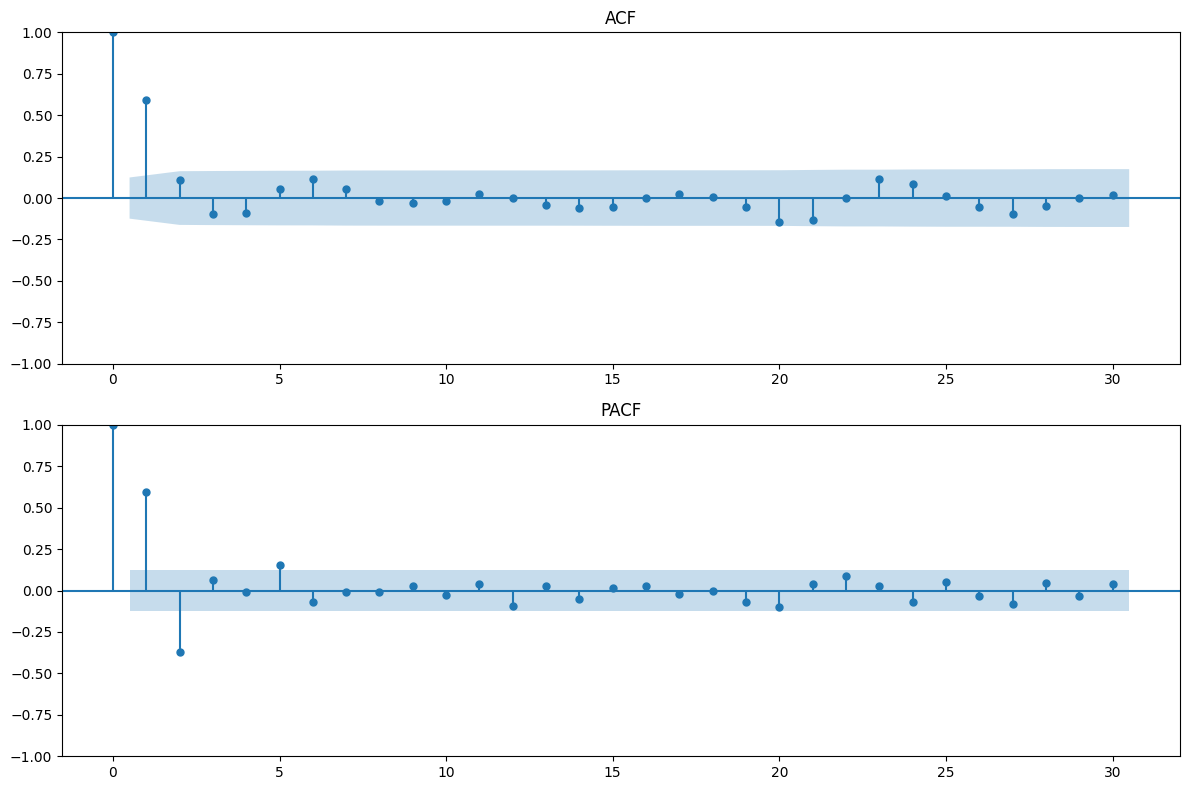


ACF는 lag=1에서 유의한 스파이크를 보이고 lag=2 이후 신뢰구간 내로 빠르게 절단되는 MA 특성을 나타낸다.

PACF는 lag=1에서 유의한 스파이크, lag=2에서 경계 수준의 음의 값을 보이며 lag=3 이후 소멸하는 AR 특성을 보인다.

두 그래프 모두 빠르게 소멸하는 패턴으로 ARMA(1,1) 또는 MA(1) 모형이 적합할 것으로 판단되며 AIC 기준으로 
최적 차수를 최종 결정한다.




In [108]:
# ── 4. ACF / PACF ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df, lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF')

plot_pacf(df, lags=30, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

# ACF와 PACF를 그려 해석하고 이를 바탕으로 적절한 ARMA (p, q) 모형을 제시
# ACF 점차적으로 감소 p 이후의 절단 점 : q = 1
# PACF 점차적으로 감소 p = 1,2 
# ACF -> MA q 특성
# PACF -> AR p 특성

print('''
ACF는 lag=1에서 유의한 스파이크를 보이고 lag=2 이후 신뢰구간 내로 빠르게 절단되는 MA 특성을 나타낸다.

PACF는 lag=1에서 유의한 스파이크, lag=2에서 경계 수준의 음의 값을 보이며 lag=3 이후 소멸하는 AR 특성을 보인다.

두 그래프 모두 빠르게 소멸하는 패턴으로 ARMA(1,1) 또는 MA(1) 모형이 적합할 것으로 판단되며 AIC 기준으로 
최적 차수를 최종 결정한다.

''')